In [10]:
import datetime
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import List, Dict, Optional

# Реализуем класс Account

In [ ]:
class Account:
    _account_counter = 1000

    def __init__(self, account_holder: str, balance: float = 0):
        """Инициализация счета"""
        self._validate_holder_name(account_holder)
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным")

        Account._account_counter += 1
        self.account_number = f'ACC-{Account._account_counter}'

        self.holder = account_holder
        self._balance = balance
        self.operations_history = []

        if balance > 0:
            self._add_operation('initial_deposit', balance, 'success')

    @staticmethod
    def _validate_holder_name(name: str):
        """Проверка, что имя в формате 'Имя Фамилия' с заглавных букв."""
        pattern = r'^[A-ZА-ЯЁ][a-zа-яё]+ [A-ZА-ЯЁ][a-zа-яё]+$'
        if not re.match(pattern, name):
            raise ValueError("Имя владельца должно быть в формате 'Имя Фамилия'")

    def _add_operation(self, operation_type: str, amount: float, status: str, timestamp=None):
        """Добавление операции в историю"""
        operation = {
            'type': operation_type,
            'amount': amount,
            'timestamp': timestamp or datetime.datetime.now(),
            'balance_after': self._balance,
            'status': status,
            'account_number': self.account_number,
            'holder': self.holder,
            'account_type': getattr(self, "account_type", "base")
        }
        self.operations_history.append(operation)

    def deposit(self, amount: float) -> bool:
        """Пополнение счета"""
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной")
        try:
            self._balance += amount
            self._add_operation('deposit', amount, 'success')
            return True
        except Exception:
            self._add_operation('deposit', amount, 'fail')
            return False

    def withdraw(self, amount: float) -> bool:
        """Снятие средств со счета"""
        if amount <= 0 or amount > self._balance:
            self._add_operation('withdraw', amount, 'fail')
            return False
        try:
            self._balance -= amount
            self._add_operation('withdraw', amount, 'success')
            return True
        except Exception:
            self._add_operation('withdraw', amount, 'fail')
            return False

    def get_balance(self) -> float:
        return self._balance

    def get_history(self) -> List[Dict]:
        return self.operations_history.copy()

    def load_history_from_file(self, filepath: str):
        """Загружает историю транзакций из CSV или JSON файла"""
        print(f"\nЗагрузка данных из файла: {filepath}")
        if filepath.endswith('.csv'):
            df = pd.read_csv(filepath)
        elif filepath.endswith('.json'):
            df = pd.read_json(filepath)
        else:
            raise ValueError("Поддерживаются только CSV и JSON файлы")

        # Фильтруем по номеру текущего счёта
        df = df[df['account_number'] == self.account_number]

        if df.empty:
            print(f"Для счёта {self.account_number} нет транзакций в файле.")
            return

        clean_df = self.clean_history(df)
        if clean_df.empty:
            print("Нет валидных записей после очистки данных.")
            return

        clean_df = clean_df.sort_values('date')

        # Добавляем операции в историю и пересчитываем баланс
        for _, row in clean_df.iterrows():
            op_type = row['operation']
            amount = float(row['amount'])
            status = row.get('status', 'success')

            if op_type == 'deposit':
                self._balance += amount
            elif op_type == 'withdraw':
                self._balance -= amount
            elif op_type == 'interest' and hasattr(self, 'apply_interest'):
                self._balance += amount  # уже начисленные проценты

            self._add_operation(op_type, amount, status, timestamp=row['date'])

    def clean_history(self, df: pd.DataFrame) -> pd.DataFrame:
        """Проверяет и очищает ошибки в данных"""
        df = df.copy()
        print("Очистка данных...")

        valid_operations = ['deposit', 'withdraw']
        if isinstance(self, SavingsAccount):
            valid_operations.append('interest')

        def parse_date_safe(date_str):
            for fmt in ("%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M"):
                try:
                    return datetime.datetime.strptime(date_str, fmt)
                except Exception:
                    continue
            return None

        cleaned_rows = []
        for _, row in df.iterrows():
            op = str(row.get('operation', '')).strip().lower()
            amt = row.get('amount', None)
            date_str = str(row.get('date', '')).strip()
            status = str(row.get('status', '')).lower()

            # Проверка даты
            date_obj = parse_date_safe(date_str)
            if date_obj is None:
                continue

            # Проверка суммы
            try:
                amt = float(amt)
                if amt <= 0 or pd.isna(amt):
                    continue
            except Exception:
                continue

            # Проверка типа операции и статуса
            if op not in valid_operations:
                continue
            if status != 'success':
                continue

            cleaned_rows.append({
                'operation': op,
                'amount': amt,
                'date': date_obj,
                'status': status
            })

        print(f"Валидных строк: {len(cleaned_rows)} из {len(df)}")
        return pd.DataFrame(cleaned_rows)

    def analyze_large_operations(self, n: int = 5):
        if not self.operations_history:
            print("История операций пуста.")
            return
        df = pd.DataFrame(self.operations_history)
        largest = df.sort_values("amount", ascending=False).head(n)
        print(f"\nТоп-{n} крупных операций для {self.account_number}:")
        print(largest[['timestamp', 'type', 'amount', 'status', 'balance_after']])

    def plot_history(self, save_path: Optional[str] = None):
        if not self.operations_history:
            print("История операций пуста")
            return
        df = pd.DataFrame(self.get_history()).sort_values('timestamp')

        plt.figure(figsize=(12, 6))
        plt.plot(df['timestamp'], df['balance_after'],
                 marker='o', linewidth=2, markersize=6, label='Баланс')

        success_ops = df[df['status'] == 'success']
        colors = ['green' if t == 'deposit' else 'red' if t == 'withdraw' else 'blue'
                  for t in success_ops['type']]
        plt.scatter(success_ops['timestamp'], success_ops['balance_after'],
                    c=colors, s=100, alpha=0.7, zorder=5)

        plt.title(f'{self.account_type.capitalize()} счёт {self.account_number}\nВладелец: {self.holder}',
                  fontsize=14, fontweight='bold')
        plt.xlabel('Время операции')
        plt.ylabel('Баланс')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

        legend_elements = [
            Patch(color='green', label='Пополнение'),
            Patch(color='red', label='Снятие'),
            Patch(color='blue', label='Другие операции')
        ]
        plt.legend(handles=legend_elements)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен как {save_path}")
        plt.show()


# Реализуем класс CheckingAccount

In [23]:
class CheckingAccount(Account):
    """Расчётный счёт"""
    account_type = "checking"

# Реализуем класс SavingsAccount

In [27]:
class SavingsAccount(Account):
    """Сберегательный счёт"""
    account_type = "savings"

    # Переопределим метод
    def withdraw(self, amount: float) -> bool:
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной")
        if amount > self._balance * 0.5:
            print("Нельзя снять более 50% от текущего баланса.")
            self._add_operation('withdraw', amount, 'fail')
            return False
        return super().withdraw(amount)

    def apply_interest(self, rate: float):
        if rate < 0:
            raise ValueError("Процентная ставка не может быть отрицательной")
        interest = self._balance * (rate / 100)
        self._balance += interest
        self._add_operation('interest', interest, 'success')

# Проведем тестирование

Баланс acc1 после пополнения: 1500
Баланс acc2 после пополнения: 3000
Нельзя снять более 50% от текущего баланса.
Баланс acc1 после снятия: 1200
Баланс acc2 после снятия: 1800
Баланс acc2 после начисления процентов: 1890.00
--- Анализ крупных операций ---

Топ-3 крупных операций для ACC-1007:
                   timestamp             type  amount   status  balance_after
0 2025-11-07 16:10:34.285789  initial_deposit    1000  success           1000
1 2025-11-07 16:10:34.285877          deposit     500  success           1500
2 2025-11-07 16:10:34.286606         withdraw     300  success           1200

Топ-3 крупных операций для ACC-1008:
                   timestamp             type  amount   status  balance_after
0 2025-11-07 16:10:34.285849  initial_deposit  2000.0  success         2000.0
2 2025-11-07 16:10:34.286623         withdraw  1200.0  success         1800.0
1 2025-11-07 16:10:34.285890          deposit  1000.0  success         3000.0
--- Тестируем очистку данных ---
Очистка дан

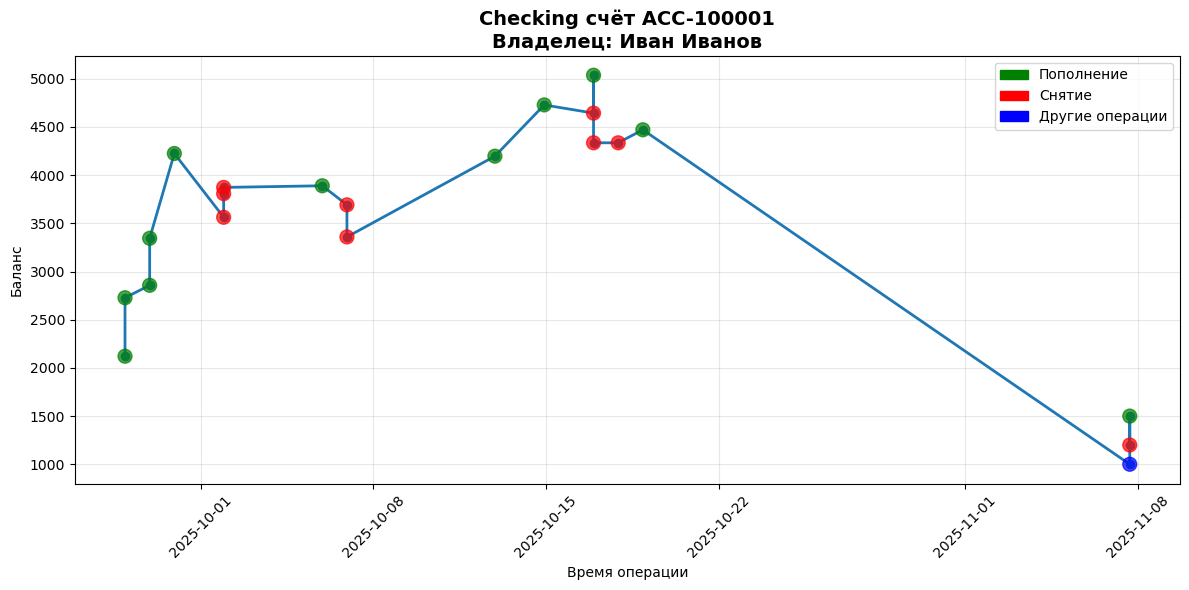

In [31]:
acc1 = CheckingAccount("Иван Иванов", 1000)
acc2 = SavingsAccount("Petr Petrov", 2000)

acc1.deposit(500)
acc2.deposit(1000)
print(f"Баланс acc1 после пополнения: {acc1.get_balance()}")
print(f"Баланс acc2 после пополнения: {acc2.get_balance()}")

acc1.withdraw(300)
acc2.withdraw(1200)
acc2.withdraw(1000)  # должно быть запрещено (более 50%)
print(f"Баланс acc1 после снятия: {acc1.get_balance()}")
print(f"Баланс acc2 после снятия: {acc2.get_balance()}")

acc2.apply_interest(5)
print(f"Баланс acc2 после начисления процентов: {acc2.get_balance():.2f}")

print("--- Анализ крупных операций ---")
acc1.analyze_large_operations(3)
acc2.analyze_large_operations(3)

print("--- Тестируем очистку данных ---")
dirty_data = pd.DataFrame({
    "operation": ["deposit", "withdraw", "withdraw", "interest", "wrongop"],
    "amount": [100, -50, 200, 30, 500],
    "date": ["2024-12-01 10:00:00", "bad_date", "2024-12-02 15:30:00", "2024-12-03 09:00:00", "2024-12-04 12:00:00"],
    "status": ["success", "success", "fail", "success", "success"]
})
cleaned = acc2.clean_history(dirty_data)
print(cleaned)

acc1.account_number = "ACC-100001"  # Принудительно ставим номер для теста
acc1.load_history_from_file("transactions_dirty.csv")

acc1.plot_history()